In [613]:
import sys
sys.path.insert(0, '../../gofher')

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from gofher import run_gofher
from visualize import create_color_map_class
import numpy as np

In [614]:
name = "NGC4501"
paper_label = "NE"
folder = "figure8"

In [615]:
path_to_input = "..\\..\\..\\spin-parity-catalog-data\\panstarrs\\{}".format(folder)
path_to_output = "..\\..\\..\\..\\"

In [616]:
def get_fits_path(name,band):
    """the file path of where existing fits files can be found"""
    return os.path.join(path_to_input,name,"{}_{}.fits".format(name,band))

def get_color_image_path(name):
    return os.path.join(path_to_input,name,"{}_color.jfif".format(name))

In [617]:
if not os.path.exists(path_to_input):
    raise ValueError("The path to the input is not found {} - make sure you update path_to_input".format(path_to_input))

if not os.path.exists(path_to_output):
    raise ValueError("The path output is not found {} - make sure you update ppath_to_output".format(path_to_output))

gal = run_gofher(name,get_fits_path,['g','r','i','z','y'],['i','z','y','r'], paper_label)

In [618]:
color_image = np.array(mpimg.imread(get_color_image_path(name)))
top = 238
color_image[top:256,:,0] =0
color_image[top:256,:,1] = 0
color_image[top:256,:,2] = 0

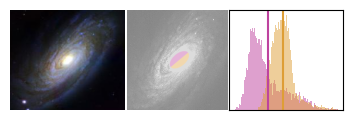

In [619]:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(10/3, 1.0))  # height can be anything

black_image = np.zeros(color_image.shape)
mid = color_image.shape[0]//2
gap = 100
axes[0].imshow(color_image[mid-gap:mid+gap, mid-gap:mid+gap],aspect='auto')
#axes[0].imshow(black_image,aspect='auto',alpha=0.21)
axes[0].set_frame_on(False)

data = gal[gal.ref_band].data
the_mask = gal[gal.ref_band].valid_pixel_mask
m, s = np.mean(data[the_mask]), np.std(data[the_mask])

el = gal.create_ellipse()
pos, neg = gal.create_bisection()
cmap = create_color_map_class(pos,neg,el)

#center_mask = [300:900, 300:900]

axes[1].imshow(data[300:900, 300:900], interpolation='nearest', cmap='gray', vmin=m-2*s, vmax=m+2*s, origin='lower')
axes[1].imshow(cmap[300:900, 300:900],origin='lower',alpha=0.4)
axes[1].set_frame_on(False)

band_pair = gal.get_band_pair('g-r')
combined = np.concatenate((band_pair.pos_side,band_pair.neg_side))
mean = np.mean(combined)
std = np.std(combined)
bins = np.linspace(mean-2*std,mean+3*std,100)
pos_counts, pos_bin_edges, _ = axes[2].hist(band_pair.pos_side,color='#BE439F',bins=bins,alpha=0.5, weights=np.ones_like(band_pair.pos_side) / len(band_pair.pos_side))
neg_counts, neg_bin_edges, _ = axes[2].hist(band_pair.neg_side,color='#DE9E36',bins=bins,alpha=0.5, weights=np.ones_like(band_pair.neg_side) / len(band_pair.neg_side))
axes[2].axvline(np.mean(band_pair.pos_side),color='#BE439F',label="{} μ = {:.3f}".format("NW",band_pair.pos_mean))
axes[2].axvline(np.mean(band_pair.neg_side),color='#DE9E36',label="{} μ = {:.3f}".format("SE",band_pair.neg_mean))
# Remove spacing between subplots
plt.subplots_adjust(wspace=0, hspace=0)
for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
fig.tight_layout(pad=0)
plt.savefig(f"{name}.png",dpi=300,bbox_inches='tight')